# Cascade Detection — `yolo26m_merged_150e` (Person -> Helmet, single weight)

| Stage | Weight | Class |
|---|---|---|
| 1 — Person | `runs/detect/yolo26m_merged_150e/weights/best.pt` | `0:person` |
| 2 — Helmet | `runs/detect/yolo26m_merged_150e/weights/best.pt` (same weight) | `1:helmet` (merged shows both; cascade helmets only) |

Valid split: `data/css-data/valid` 114 images (all 640×640). Helmet = `Hardhat` class `0` in CSS labels -> 42 helmet images. Cascade: person-det (`conf 0.5`) -> `get_head_roi()` (box-only: full width, top 45% of person height) -> batched helmet crops (`imgsz 224`, `conf 0.45`), remap to global. Figures: 42 rows x 3 cols `(person | cascade | merged)` — `merged` on rightmost shows `person+helmet` (blue+green), `cascade` orange helmets, `person` cyan ROI. Single model `yolo26m_merged_150e` used for everything.


## 1 — Setup

In [3]:
from pathlib import Path
import random, time, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, cv2
from PIL import Image
from ultralytics import YOLO

sns.set_theme(style="whitegrid")
random.seed(42)

try:
    REPO_ROOT = Path(__file__).resolve().parents[2]
except NameError:
    cur = Path.cwd()
    REPO_ROOT = cur
    for cand in [cur, cur.parent, cur.parent.parent]:
        if (cand / "YOLO8.ipynb").exists() or (cand / ".git").exists():
            REPO_ROOT = cand; break
print("REPO_ROOT:", REPO_ROOT)
print("ultralytics:", __import__("ultralytics").__version__)

MERGED_WTS = REPO_ROOT / "runs" / "detect" / "yolo26m_merged_150e" / "weights" / "best.pt"
VALID_DIR  = REPO_ROOT / "data" / "css-data" / "valid"
IMGS = sorted((VALID_DIR / "images").glob("*.jpg"))
print("MERGED_WTS:", MERGED_WTS, MERGED_WTS.exists())
print(f"valid images: {len(IMGS)}  exists={VALID_DIR.exists()}")
if IMGS:
    with Image.open(IMGS[0]) as im:
        print("example size:", im.size, IMGS[0].name[:40])

# merged: 0:person + 1:helmet (person added; helmet-only for cascade metric)
CONF_PERSON = 0.5
CONF_POSE   = CONF_PERSON  # alias for backward compat
CONF_HELMET = 0.45
CONF_SINGLE = 0.25
IMGSZ_CROP  = 224
HELMET_ID   = 1
PERSON_ID   = 0


REPO_ROOT: e:\work\P0-safety
ultralytics: 8.4.127
MERGED_WTS: e:\work\P0-safety\runs\detect\yolo26m_merged_150e\weights\best.pt True
valid images: 114  exists=True
example size: (640, 640) -1079-_png_jpg.rf.19092a3937930012f9fd9c


## 2 — Data — valid 114, helmet images (Hardhat class 0)

In [4]:
helmet_imgs = []
for im in IMGS:
    lab = VALID_DIR / "labels" / (im.stem + ".txt")
    if lab.exists():
        for line in lab.read_text().splitlines():
            if line.strip() and int(float(line.split()[0])) == 0:
                helmet_imgs.append(im)
                break
print(f"helmet images: {len(helmet_imgs)}/{len(IMGS)} (valid) -> {len(helmet_imgs)} figures")
if not helmet_imgs:
    print("no helmet images found — check data/css-data/valid/labels")

helmet images: 42/114 (valid) -> 42 figures


## 3 — Models

In [5]:
merged_model = YOLO(str(MERGED_WTS))
stage2_helmet = merged_model
stage_person = merged_model  # single weight for both stages
stage1_pose = merged_model   # alias - no separate pose weight, kept so old calls don't crash
print("yolo26m-merged ", MERGED_WTS, "exists=", MERGED_WTS.exists(), f" keep person+helmet=[{PERSON_ID},{HELMET_ID}] ->", merged_model.names)
HELMET_IDS = {HELMET_ID}
PERSON_IDS = {PERSON_ID}


yolo26m-merged  e:\work\P0-safety\runs\detect\yolo26m_merged_150e\weights\best.pt exists= True  keep person+helmet=[0,1] -> {0: 'person', 1: 'helmet', 2: 'gloves', 3: 'boots', 4: 'vest', 5: 'no-helmet', 6: 'no-gloves', 7: 'no-boots', 8: 'no-vest'}


## 4 - Head ROI (box-only, no keypoints)


In [6]:
def get_head_roi(*args, **kwargs):
    """Box-only head ROI: full person-box width, top 45% of height (chest-to-top). No keypoints.
    Supports both signatures:
      get_head_roi(person_box, img_shape)
      get_head_roi(keypoints_xy, keypoints_conf, person_box, img_shape)  # legacy - keypoints ignored
    """
    if len(args) == 2:
        person_box, img_shape = args
    elif len(args) == 4:
        _, _, person_box, img_shape = args
    elif "person_box" in kwargs and "img_shape" in kwargs:
        person_box = kwargs["person_box"]
        img_shape = kwargs["img_shape"]
    else:
        raise TypeError(f"get_head_roi expected (person_box, img_shape) or (kpts_xy, kpts_cf, person_box, img_shape), got {args} {kwargs}")
    h_img, w_img = img_shape[:2]
    bx1, by1, bx2, by2 = map(float, person_box)
    box_h = by2 - by1
    y1 = by1
    y2 = by1 + box_h * 0.45
    x1, x2 = bx1, bx2
    x1 = int(max(0, x1)); y1 = int(max(0, y1))
    x2 = int(min(w_img, x2)); y2 = int(min(h_img, y2))
    if y2 - y1 < box_h * 0.35:
        y2 = int(min(h_img, y1 + max(box_h * 0.40, 40)))
    if x2 <= x1:
        x2 = int(min(w_img, x1 + 40))
    return [x1, y1, x2, y2]


## 5 - Cascade - merged-only: person-det -> batched head crops -> global remap (helmet-only)


In [7]:
def process_frame(frame, conf_person=CONF_PERSON, conf_helmet=CONF_HELMET, imgsz_crop=IMGSZ_CROP, conf_pose=None, **kwargs):
    """2-stage cascade on BGR frame using single yolo26m_merged_150e weight. Returns list[person_entry] with helmets (id 1 only)."""
    if conf_pose is not None:
        conf_person = conf_pose
    if "conf_pose" in kwargs and kwargs["conf_pose"] is not None:
        conf_person = kwargs["conf_pose"]
    res = stage_person(frame, conf=conf_person, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        return []
    boxes = res.boxes.xyxy.cpu().numpy()
    clss = res.boxes.cls.cpu().numpy().astype(int)
    person_boxes = []
    for i, c in enumerate(clss):
        if c == PERSON_ID:
            person_boxes.append(boxes[i])
    if not person_boxes:
        return []
    import numpy as _np
    person_boxes = _np.array(person_boxes)
    crops, offsets, p_indices = [], [], []
    for idx, p_box in enumerate(person_boxes):
        roi = get_head_roi(p_box, frame.shape)
        x1, y1, x2, y2 = roi
        if (x2 - x1) > 10 and (y2 - y1) > 10:
            crops.append(frame[y1:y2, x1:x2])
            offsets.append((x1, y1))
            p_indices.append(idx)
    if not crops:
        return []
    helmet_results = stage2_helmet(crops, imgsz=imgsz_crop, conf=conf_helmet, verbose=False)
    out = []
    for p_idx, res2, (ox, oy) in zip(p_indices, helmet_results, offsets):
        entry = {"person_id": int(p_idx), "person_box": person_boxes[p_idx].tolist(), "helmets": [], "head_roi": [ox, oy, ox + crops[p_indices.index(p_idx)].shape[1], oy + crops[p_indices.index(p_idx)].shape[0]]}
        if res2.boxes is not None and len(res2.boxes) > 0:
            for l_box, conf, cls_id in zip(res2.boxes.xyxy.cpu().numpy(), res2.boxes.conf.cpu().numpy(), res2.boxes.cls.cpu().numpy()):
                if int(cls_id) not in HELMET_IDS:
                    continue
                gbox = [int(l_box[0] + ox), int(l_box[1] + oy), int(l_box[2] + ox), int(l_box[3] + oy)]
                entry["helmets"].append({"box": gbox, "confidence": float(conf), "class_id": int(cls_id), "class_name": stage2_helmet.names[int(cls_id)]})
        out.append(entry)
    return out

def single_helmet_boxes(image_path, conf=CONF_SINGLE):
    r = stage2_helmet(str(image_path), verbose=False, conf=conf)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return []
    out = []
    for i in range(len(r.boxes)):
        if int(r.boxes.cls[i].item()) in HELMET_IDS:
            x1, y1, x2, y2 = r.boxes.xyxy[i].tolist()
            out.append([x1, y1, x2, y2, float(r.boxes.conf[i].item())])
    return out

def merged_single_boxes(image_path, conf=CONF_SINGLE):
    """yolo26m_merged single-pass: returns (person_boxes, helmet_boxes) - both at same conf."""
    r = stage2_helmet(str(image_path), verbose=False, conf=conf)[0]
    persons, helmets = [], []
    if r.boxes is not None and len(r.boxes) > 0:
        for i in range(len(r.boxes)):
            cid = int(r.boxes.cls[i].item()); x1, y1, x2, y2 = r.boxes.xyxy[i].tolist(); cf = float(r.boxes.conf[i].item())
            if cid == PERSON_ID:
                persons.append([x1, y1, x2, y2, cf])
            elif cid in HELMET_IDS:
                helmets.append([x1, y1, x2, y2, cf])
    return persons, helmets


## 6 - Demo on one helmet image - person / cascade / merged (merged-only, same weight)


demo image: youtube-697_jpg.rf.950b34f23e196850ec51a4add2eeb840.jpg
merged single  persons=1 helmets=1  |  cascade persons=1 helmets=1  (conf single 0.25 / cascade 0.45)


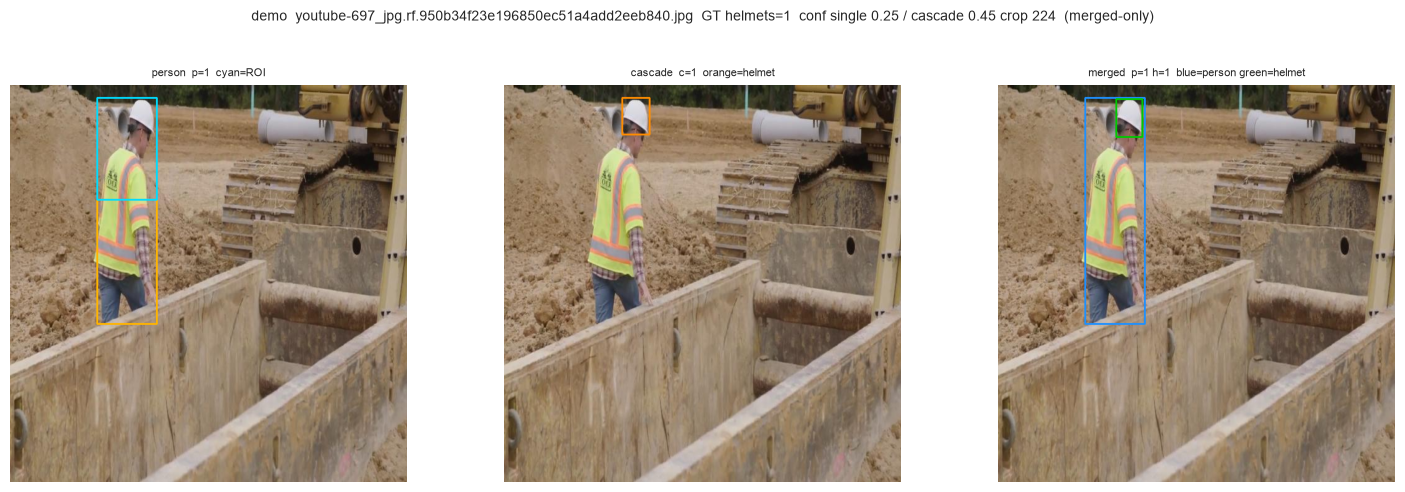

In [8]:
if helmet_imgs:
    p = random.choice(helmet_imgs)
    print("demo image:", p.name)
    persons_m, helmets_m = merged_single_boxes(p, CONF_SINGLE)
    img_bgr = cv2.imread(str(p))
    dets = process_frame(img_bgr, CONF_PERSON, CONF_HELMET, IMGSZ_CROP)
    cascade_n = sum(len(d["helmets"]) for d in dets)
    print(f"merged single  persons={len(persons_m)} helmets={len(helmets_m)}  |  cascade persons={len(dets)} helmets={cascade_n}  (conf single {CONF_SINGLE} / cascade {CONF_HELMET})")
    with Image.open(p) as pil:
        base = __import__("numpy").array(pil)
    lab = VALID_DIR / "labels" / (p.stem + ".txt")
    gt_n = sum(1 for l in lab.read_text().splitlines() if l.strip() and int(float(l.split()[0]))==0) if lab.exists() else 0
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"demo  {p.name}  GT helmets={gt_n}  conf single {CONF_SINGLE} / cascade {CONF_HELMET} crop {IMGSZ_CROP}  (merged-only)", fontsize=10)
    vis0 = base.copy()
    for d in dets:
        x1, y1, x2, y2 = map(int, d["person_box"])
        cv2.rectangle(vis0, (x1, y1), (x2, y2), (255, 180, 0), 2)
        hx1, hy1, hx2, hy2 = map(int, d["head_roi"])
        cv2.rectangle(vis0, (hx1, hy1), (hx2, hy2), (0, 220, 255), 2)
    axes[0].imshow(vis0); axes[0].set_title(f"person  p={len(dets)}  cyan=ROI", fontsize=8); axes[0].axis("off")
    vis1 = base.copy()
    for d in dets:
        for h in d["helmets"]:
            x1, y1, x2, y2 = h["box"]
            cv2.rectangle(vis1, (x1, y1), (x2, y2), (255, 140, 0), 2)
    axes[1].imshow(vis1); axes[1].set_title(f"cascade  c={cascade_n}  orange=helmet", fontsize=8); axes[1].axis("off")
    vis2 = base.copy()
    for x1, y1, x2, y2, _ in persons_m:
        cv2.rectangle(vis2, (int(x1), int(y1)), (int(x2), int(y2)), (30, 144, 255), 2)
    for x1, y1, x2, y2, _ in helmets_m:
        cv2.rectangle(vis2, (int(x1), int(y1)), (int(x2), int(y2)), (0, 200, 0), 2)
    axes[2].imshow(vis2); axes[2].set_title(f"merged  p={len(persons_m)} h={len(helmets_m)}  blue=person green=helmet", fontsize=8); axes[2].axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()


## 7 - Visuals - 42 rows, 3 cols (person | cascade | merged) - single weight yolo26m_merged_150e


helmet images: 42/114 (valid) -> 42 figures  (yolo26m_merged_150e only)


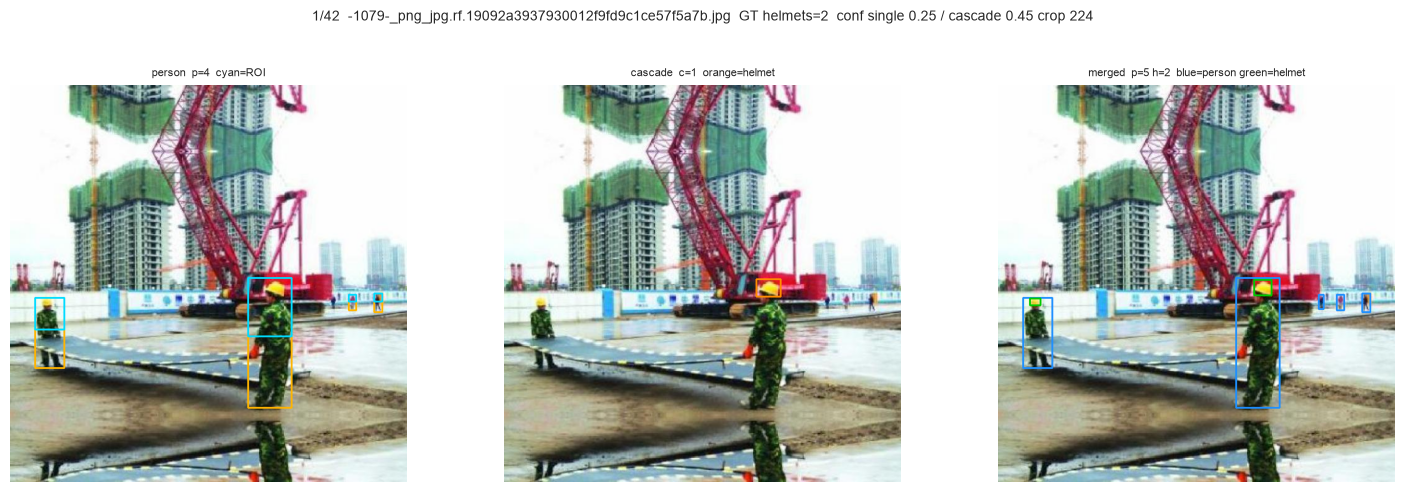

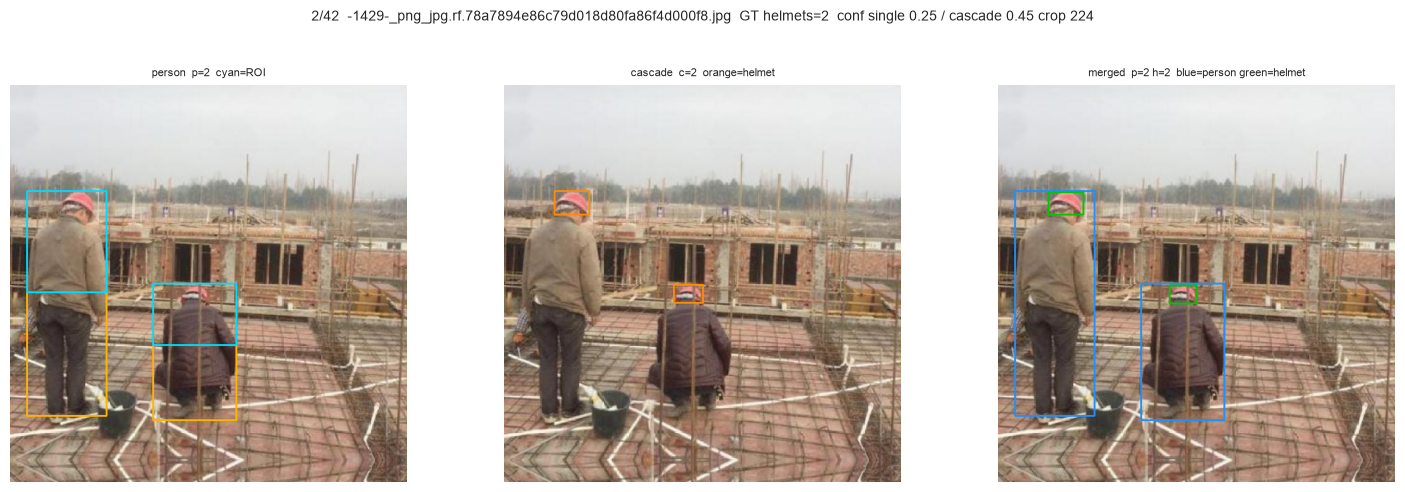

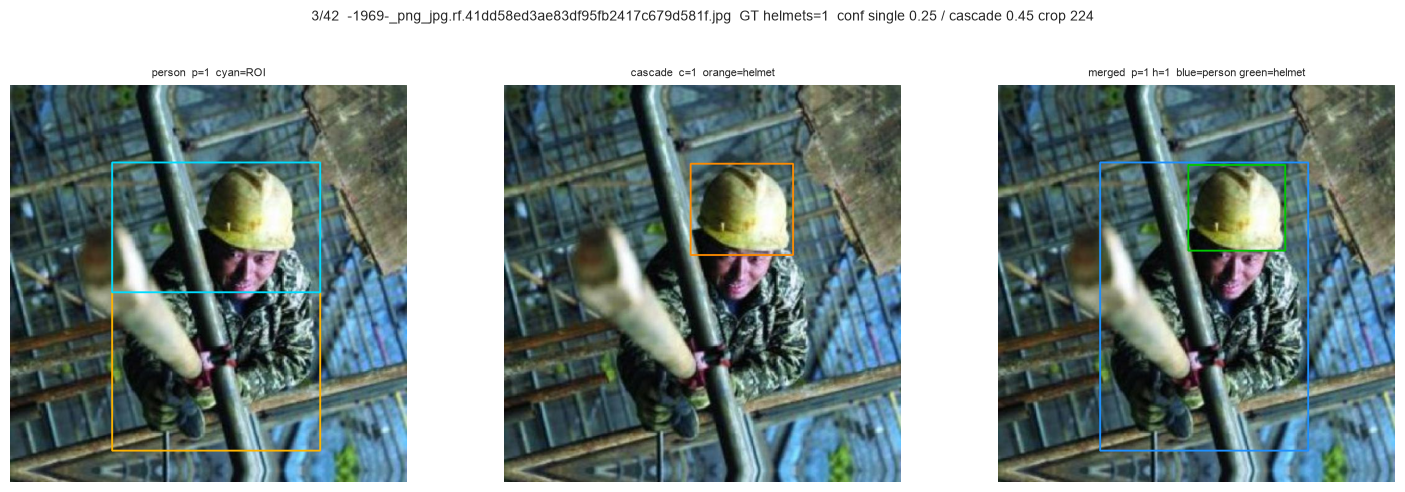

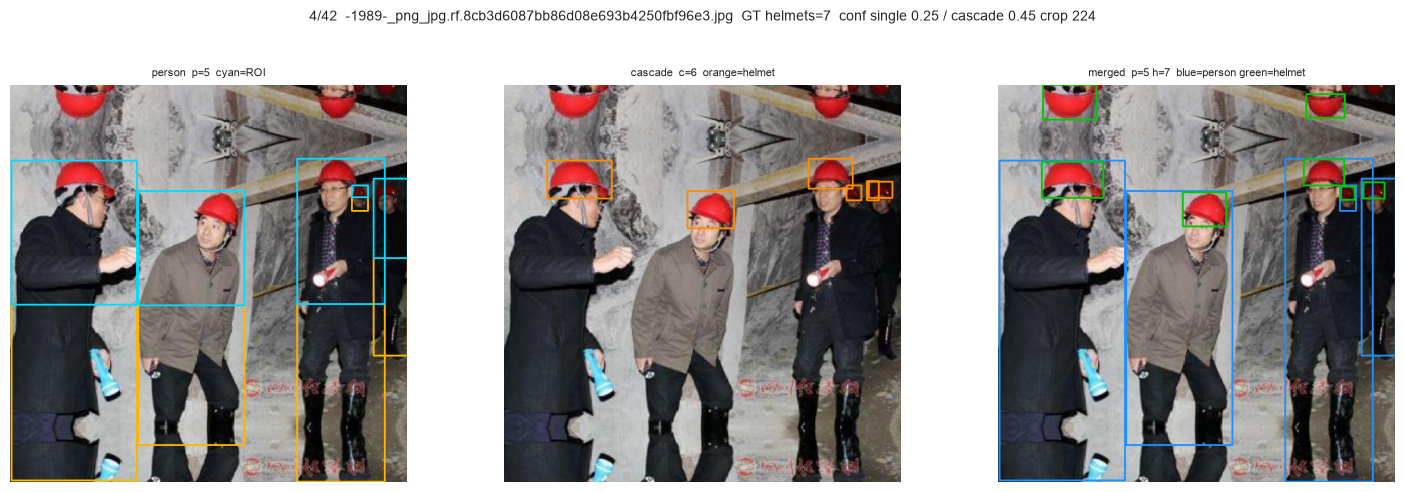

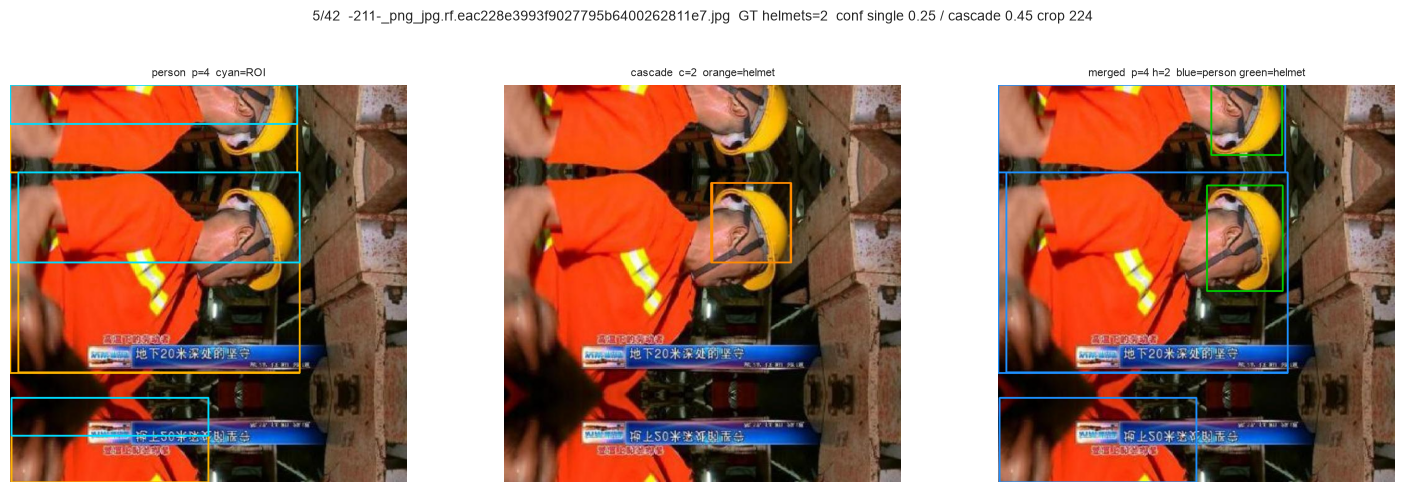

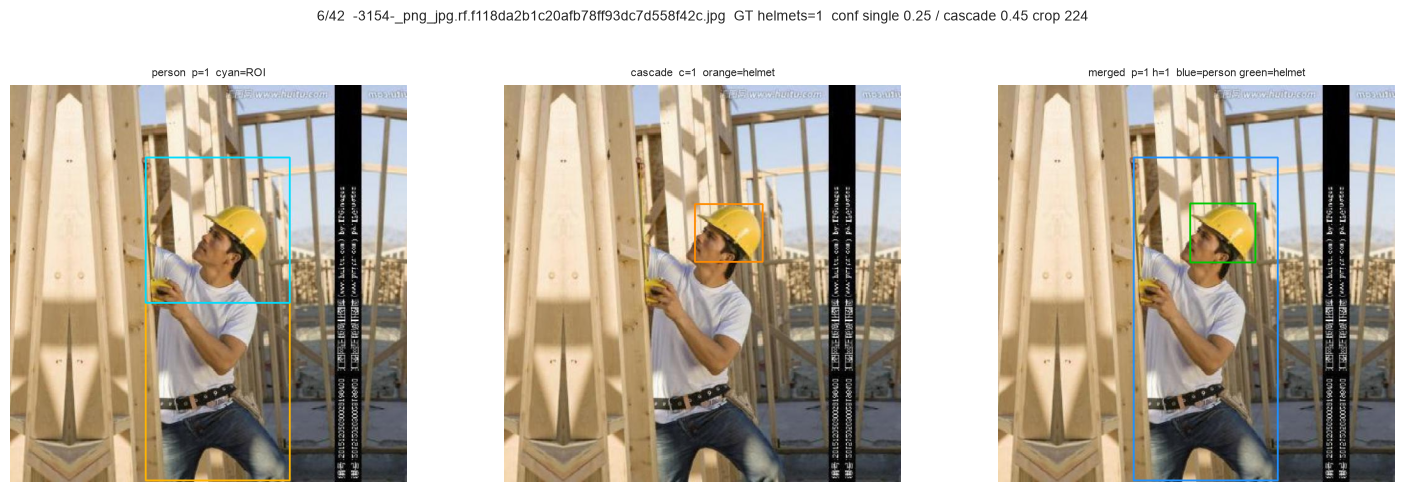

In [ ]:
if not IMGS:
    print("no images")
elif not helmet_imgs:
    print("no helmet images found")
else:
    print(f"helmet images: {len(helmet_imgs)}/{len(IMGS)} (valid) -> {len(helmet_imgs)} figures  (yolo26m_merged_150e only)")
    for idx, im in enumerate(helmet_imgs, 1):
        with Image.open(im) as pil:
            base = __import__("numpy").array(pil)
        lab = VALID_DIR / "labels" / (im.stem + ".txt")
        gt_n = sum(1 for l in lab.read_text().splitlines() if l.strip() and int(float(l.split()[0]))==0) if lab.exists() else 0
        persons_m, helmets_m = merged_single_boxes(im, CONF_SINGLE)
        img_bgr = cv2.imread(str(im))
        dets = process_frame(img_bgr, CONF_PERSON, CONF_HELMET, IMGSZ_CROP) if img_bgr is not None else []
        cascade_n = sum(len(d["helmets"]) for d in dets)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"{idx}/{len(helmet_imgs)}  {im.name}  GT helmets={gt_n}  conf single {CONF_SINGLE} / cascade {CONF_HELMET} crop {IMGSZ_CROP}", fontsize=10)
        vis0 = base.copy()
        for d in dets:
            x1, y1, x2, y2 = map(int, d["person_box"])
            cv2.rectangle(vis0, (x1, y1), (x2, y2), (255, 180, 0), 2)
            hx1, hy1, hx2, hy2 = map(int, d["head_roi"])
            cv2.rectangle(vis0, (hx1, hy1), (hx2, hy2), (0, 220, 255), 2)
        axes[0].imshow(vis0)
        axes[0].set_title(f"person  p={len(dets)}  cyan=ROI", fontsize=8)
        axes[0].axis("off")
        vis1 = base.copy()
        for d in dets:
            for h in d["helmets"]:
                x1, y1, x2, y2 = h["box"]
                cv2.rectangle(vis1, (x1, y1), (x2, y2), (255, 140, 0), 2)
        axes[1].imshow(vis1)
        axes[1].set_title(f"cascade  c={cascade_n}  orange=helmet", fontsize=8)
        axes[1].axis("off")
        vis2 = base.copy()
        for x1, y1, x2, y2, _ in persons_m:
            cv2.rectangle(vis2, (int(x1), int(y1)), (int(x2), int(y2)), (30, 144, 255), 2)
        for x1, y1, x2, y2, _ in helmets_m:
            cv2.rectangle(vis2, (int(x1), int(y1)), (int(x2), int(y2)), (0, 200, 0), 2)
        axes[2].imshow(vis2)
        axes[2].set_title(f"merged  p={len(persons_m)} h={len(helmets_m)}  blue=person green=helmet", fontsize=8)
        axes[2].axis("off")
        plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()


## 8 - Batch eval - valid 114 (merged-only)


In [ ]:
from tqdm import tqdm

def run_split(split="valid", conf_person=CONF_PERSON, conf_helmet=CONF_HELMET, conf_single=CONF_SINGLE, limit=None, conf_pose=None):
    if conf_pose is not None:
        conf_person = conf_pose
    img_dir = VALID_DIR if split == "valid" else REPO_ROOT / "data" / "css-data" / split / "images"
    if split == "valid":
        img_dir = VALID_DIR / "images"
    if not img_dir.exists():
        print(f"{img_dir} missing - skip"); return []
    paths = sorted(img_dir.glob("*.jpg"))
    if limit: paths = paths[:limit]
    rows = []; t0 = time.time()
    for p in tqdm(paths, desc=split):
        lab = (VALID_DIR / "labels" / (p.stem + ".txt") if split == "valid" else p.parent.parent / "labels" / (p.stem + ".txt"))
        gt_n = sum(1 for l in lab.read_text().splitlines() if l.strip() and int(float(l.split()[0]))==0) if lab.exists() else 0
        t = time.time()
        single = single_helmet_boxes(p, conf_single)
        img = cv2.imread(str(p))
        dets = process_frame(img, conf_person, conf_helmet, IMGSZ_CROP) if img is not None else []
        cascade_n = sum(len(d["helmets"]) for d in dets)
        rows.append({"image": p.name, "gt": gt_n, "persons": len(dets), "single": len(single), "cascade": cascade_n, "ms": (time.time() - t) * 1000, "detections": dets})
    print(f"{split}: {len(rows)} imgs, avg {(time.time() - t0) / max(1, len(rows)) * 1000:.0f} ms/img  (yolo26m_merged_150e only)")
    return rows

# quick check on 20 helmet-relevant images
rows = run_split("valid", limit=20)
if rows:
    print(f"avg persons/img: {__import__('numpy').mean([r['persons'] for r in rows]):.2f}  avg single/img: {__import__('numpy').mean([r['single'] for r in rows]):.2f}  avg cascade/img: {__import__('numpy').mean([r['cascade'] for r in rows]):.2f}")
    df = pd.DataFrame(rows)
    plt.figure(figsize=(12, 4))
    x = __import__("numpy").arange(len(df))
    plt.bar(x - 0.2, df["single"], width=0.4, label="single", color="#2ca02c", alpha=0.85)
    plt.bar(x + 0.2, df["cascade"], width=0.4, label="cascade", color="#ff7f0e", alpha=0.85)
    plt.xticks(x, df["image"].str[:18], rotation=45, ha="right", fontsize=7)
    plt.ylabel("helmet count")
    plt.title("Single (green) vs cascade (orange) helmet detections - valid first 20  (merged-only)")
    plt.legend(); plt.tight_layout(); plt.show()
